In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


# 预处理

In [2]:
# 加载FashionMNIST数据集
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将PIL图像或numpy数组转换为tensor,ToTensor会自动将图像转换为tensor，并归一化到[0,1]范围
    transforms.Normalize((0.2860,), (0.3530,))  # 标准化到[-1, 1]范围
])

# 下载并加载训练集
train_dataset = datasets.FashionMNIST(
    root='./data',  # 数据存储路径
    train=True,     # 加载训练集
    download=True,  # 如果数据不存在则下载
    transform=transform
)

# 下载并加载测试集
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,    # 加载测试集
    download=True,
    transform=transform
)

# 打印数据集信息
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

# lables在这个路径https://github.com/zalandoresearch/fashion-mnist
# FashionMNIST类别标签
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")


训练集大小: 60000
测试集大小: 10000
类别数量: 10
类别标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [3]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
    num_workers=2  # 使用多进程加载数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
    num_workers=2
)

# 搭建DNN

In [ ]:
import torch
import torch.nn as nn

# 定义一个深度前馈神经网络（DNN）模型
# DNN（深度前馈神经网络, Deep Neural Network）是一类由多层线性映射（全连接/线性层）和非线性激活函数（如ReLU）叠加组成的神经网络。
# 它的输入通常是一维向量，通过多层隐含层的变换，学习输入和输出之间的复杂关系。
# DNN的每一层都尝试提取输入数据中更高级、更抽象的特征，适用于图像分类、语音识别、文本分析等任务。
# DNN的一般结构为：输入层 -> 多个（线性层+激活）隐藏层 -> 输出层（通常用于分类或回归任务）。

class DNN(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10, hidden_size=100, num_hidden_layers=19):
        """
        初始化DNN模型。

        参数:
        - input_size: 输入特征的维度，这里默认为28*28，因为输入为FashionMNIST的图像（28x28）。
        - num_classes: 输出类别的数量，这里默认为10。
        - hidden_size: 每个隐藏层的神经元数量，默认为100。
        - num_hidden_layers: 隐藏层的总数，默认为19。
        """
        # 调用父类nn.Module的初始化方法，确保模型各组件能够被正确注册和管理
        super(DNN, self).__init__()

        layers = []

        # 为什么要把第一个单独写？因为第一个线性层的输入维度是input_size（比如28*28），
        # 而所有后续的隐藏层输入都是hidden_size，所以第一个需要单独处理，后面可以用循环加（hidden_size, hidden_size）。
        layers.append(nn.Linear(input_size, hidden_size))  # 第一个全连接层
        layers.append(nn.ReLU())  # 非线性激活

        # 通过for循环添加剩余的隐藏层（每层都有线性层+ReLU）
        for i in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))  # 隐藏层
            layers.append(nn.ReLU())  # 非线性激活

        # 输出层，不加激活，因为后续使用CrossEntropyLoss
        layers.append(nn.Linear(hidden_size, num_classes))  # 输出层

        # 使用nn.Sequential将所有层组合在一起
        self.layers = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        前向传播函数。

        输入:
        - x: 输入张量，形状为(batch_size, 1, 28, 28)。

        过程:
        - 首先将x展平为(batch_size, 28*28)，
        - 然后依次通过各层得到输出。

        返回:
        - 输出张量，形状为(batch_size, num_classes)。
        """
        # x.size(0) 表示batch的大小，例如32，-1表示自动推算维度，将(32, 1, 28, 28)展平为(32, 784)
        # 语法: x.view(batch_size, -1) 中 -1 让PyTorch自动计算展开后的特征维数
        x = x.view(x.size(0), -1)  # 展平成二维，方便送入全连接层
        # self.layers是nn.Sequential对象，将x依次通过各层（线性层+激活函数等）处理，得到最终输出

        # INSERT_YOUR_CODE
        # layers最初是一个Python的列表，列表中依次加入了所有要用到的层（nn.Linear、nn.ReLU等）。
        # 但是PyTorch的nn.Module（包括nn.Sequential）只会自动注册其属性中被"赋值"为nn.Module对象的成员，
        # 而不会自动注册Python列表等容器的内容。
        # nn.Sequential的作用是把一个层的列表封装成一个整体网络，可以像普通nn.Module一样调用和管理。
        # 使用方式: nn.Sequential(*layers)
        # 这样可以让网络方便地“按顺序”依次通过这些层。
        # 例如 self.layers(x) 就等价于依次执行每个layers中的模块，对x逐步变换，结构非常清晰。
        # 举个例子:
        # layers = [nn.Linear(784, 100), nn.ReLU(), nn.Linear(100, 10)]
        # self.layers = nn.Sequential(*layers)
        # 调用: output = self.layers(x)
        # 就相当于 x → Linear → ReLU → Linear → output

        
        x = self.layers(x)
        return x

# 创建DNN模型实例，指定输入维度与输出类别数
model = DNN(input_size=28*28, num_classes=10)

# 打印模型结构，方便检查
print(model)

# 统计并打印模型的参数总数
# 计算并打印模型的参数总数
# - model.parameters() 返回模型中所有可学习参数（权重、偏置等）的迭代器
# - p.numel() 计算每个参数张量包含的元素个数（即参数个数）
# - sum(...) 求所有参数张量的元素个数之和，即为总参数量
# 用法示例如下：
print(f"\n模型参数总数: {sum(p.numel() for p in model.parameters())}")



DNN(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=100, bias=True)
    (7): ReLU()
    (8): Linear(in_features=100, out_features=100, bias=True)
    (9): ReLU()
    (10): Linear(in_features=100, out_features=100, bias=True)
    (11): ReLU()
    (12): Linear(in_features=100, out_features=100, bias=True)
    (13): ReLU()
    (14): Linear(in_features=100, out_features=100, bias=True)
    (15): ReLU()
    (16): Linear(in_features=100, out_features=100, bias=True)
    (17): ReLU()
    (18): Linear(in_features=100, out_features=100, bias=True)
    (19): ReLU()
    (20): Linear(in_features=100, out_features=100, bias=True)
    (21): ReLU()
    (22): Linear(in_features=100, out_features=100, bias=True)
    (23): ReLU()
    (24): Linear(in_f

In [8]:
# 验证模型前向计算
# 创建一个随机输入张量，模拟MNIST图片数据
batch_size = 32
input_tensor = torch.randn(batch_size, 1, 28, 28)  # (batch_size, channels, height, width)

print(f"输入张量形状: {input_tensor.shape}")

# 前向传播
with torch.no_grad():  # 不需要计算梯度
    output = model(input_tensor)
    
print(f"输出张量形状: {output.shape}")
print(f"输出张量示例 (前5个样本的前5个类别概率):")
print(output[:5, :5])

# 验证输出维度是否正确
assert output.shape == (batch_size, 10), f"期望输出形状为 ({batch_size}, 10), 但得到 {output.shape}"
print("\n✅ 模型前向计算验证成功！")


输入张量形状: torch.Size([32, 1, 28, 28])
输出张量形状: torch.Size([32, 10])
输出张量示例 (前5个样本的前5个类别概率):
tensor([[ 0.0701, -0.0141,  0.0750,  0.0750,  0.0707],
        [ 0.0701, -0.0141,  0.0750,  0.0750,  0.0707],
        [ 0.0701, -0.0141,  0.0750,  0.0750,  0.0707],
        [ 0.0701, -0.0141,  0.0750,  0.0750,  0.0707],
        [ 0.0701, -0.0141,  0.0750,  0.0750,  0.0707]])

✅ 模型前向计算验证成功！


In [9]:
for batch in train_loader:
    inputs, targets = batch
    print(inputs.shape)
    print(targets.shape)
    break


torch.Size([32, 1, 28, 28])
torch.Size([32])


In [10]:
# 导入训练模块
from wangdao_train import Trainer

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 初始化损失函数
criterion = torch.nn.CrossEntropyLoss()

# 初始化优化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 初始化早停
early_stopping_kwargs = {
    'patience': 10,
    'min_delta': 0.001,
    'mode': 'max'
}

# 创建训练器
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500,
    # early_stopping_kwargs=early_stopping_kwargs
)

# 开始训练
print("开始训练...")
trainer.train(num_epochs=20)


使用设备: cpu
开始训练...
[Step 500] Val Loss: 1.0643 Val Acc: 0.5152
[Step 1000] Val Loss: 0.8547 Val Acc: 0.6943
[Step 1500] Val Loss: 0.8640 Val Acc: 0.6702
Epoch [1/20]  Train Loss: 1.0221  Train Acc: 0.6046
[Step 2000] Val Loss: 0.8859 Val Acc: 0.6837
[Step 2500] Val Loss: 0.7333 Val Acc: 0.7503
[Step 3000] Val Loss: 0.6536 Val Acc: 0.7733
[Step 3500] Val Loss: 0.6824 Val Acc: 0.7529
Epoch [2/20]  Train Loss: 0.7002  Train Acc: 0.7485
[Step 4000] Val Loss: 0.7783 Val Acc: 0.7167
[Step 4500] Val Loss: 1.1648 Val Acc: 0.5460
[Step 5000] Val Loss: 0.8756 Val Acc: 0.7068
[Step 5500] Val Loss: 0.7586 Val Acc: 0.7542
Epoch [3/20]  Train Loss: 0.8100  Train Acc: 0.7145
[Step 6000] Val Loss: 0.7206 Val Acc: 0.7687
[Step 6500] Val Loss: 0.6737 Val Acc: 0.7763
[Step 7000] Val Loss: 0.6604 Val Acc: 0.7713
[Step 7500] Val Loss: 0.7213 Val Acc: 0.7650
Epoch [4/20]  Train Loss: 0.7079  Train Acc: 0.7571
[Step 8000] Val Loss: 0.6462 Val Acc: 0.7812
[Step 8500] Val Loss: 0.8304 Val Acc: 0.6919
[Step 9000

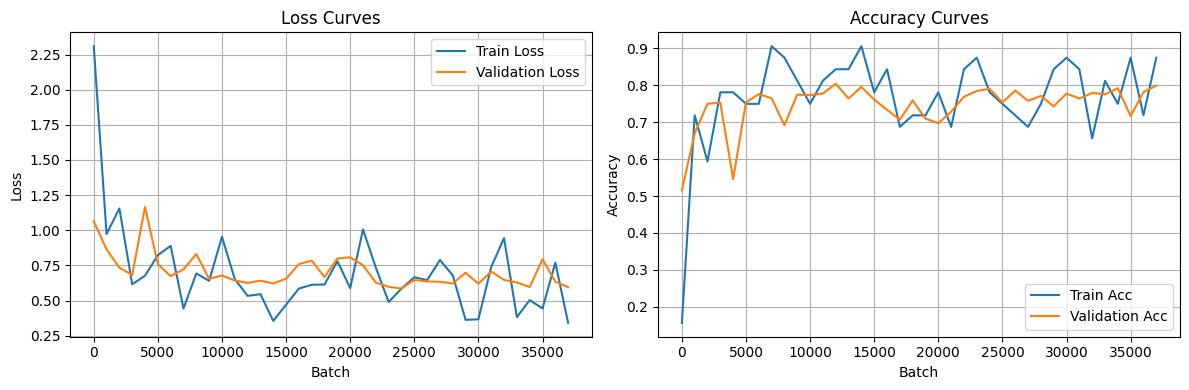

In [11]:
trainer.plot_curves()